In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-20.csv
/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-80.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-20.csv
/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-80.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
# load the data

train_df = pd.read_csv('/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-80.csv')
test_df = pd.read_csv('/kaggle/input/datasets/jharilova/chunk-data/Churn Prdiction Data/churn-bigml-20.csv')

In [5]:
# combine the data
df = pd.concat([train_df, test_df], ignore_index = True)
print(f"Total row combined : {df.shape[0]}")
print(f"Columns : {df.columns.tolist()}")

Total row combined : 3333
Columns : ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


# Prepare the features (drop target and non useful columns)

In [6]:
# Drop the target 'Churn' (we don't use it for clustering)
# Also drop 'State' (high cardinality) and 'Area code' (low variance) if present
X = df.drop(["Churn", 'State', "Area code"], axis =1, errors= 'ignore')

In [7]:
# Encode binary categorical features
if 'International plan' in X.columns:
    X['International plan'] = X['International plan'].map({'Yes': 1, 'No': 0})
if 'Voice mail plan' in X.columns:
    X['Voice mail plan'] = X['Voice mail plan'].map({'Yes': 1, 'No': 0})

# Check for any remaining object columns – encode if needed
for col in X.select_dtypes(include=['object']).columns:
    print(f"Encoding column: {col}")
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print("Features ready for clustering:")
print(X.head())

Features ready for clustering:
   Account length  International plan  Voice mail plan  Number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   
2             137                   0                0                      0   
3              84                   1                0                      0   
4              75                   1                0                      0   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0              265.1              110             45.07              197.4   
1              161.6              123             27.47              195.5   
2              243.4              114             41.38              121.2   
3              299.4               71             50.90               61.9   
4              166.7              113             28.34              148.3   

   Total eve 

# Scale feature for k-Means

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

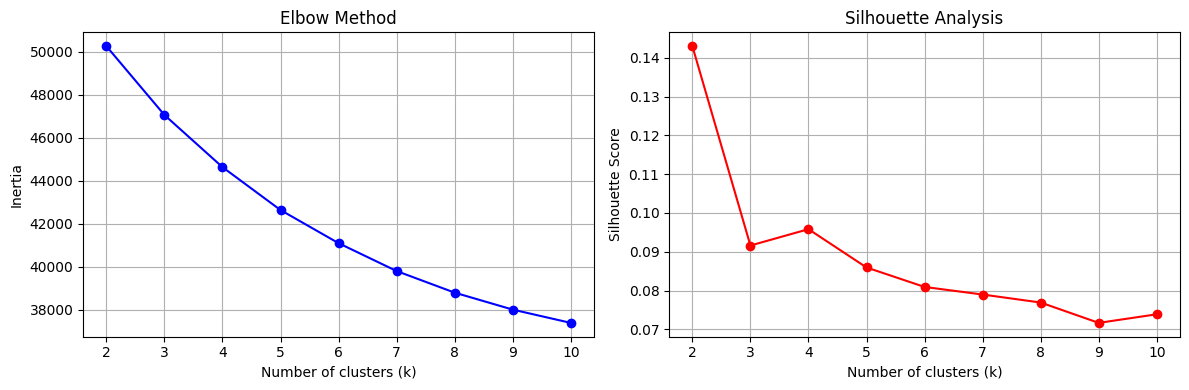

In [9]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Based on plots, choose k (e.g., 3 or 4). Let's pick k=3 for this example.
optimal_k = 3   # You may change after visual inspection
print(f"Chosen number of clusters: {optimal_k}")

Chosen number of clusters: 3


# Apply k-mean with optimal

In [11]:
kmeans_final = KMeans(n_clusters = optimal_k, random_state = 42, n_init =10)
clusters = kmeans_final.fit_predict(X_scaled)
df["Cluster"] = clusters

# Visualisation cluster using PCA

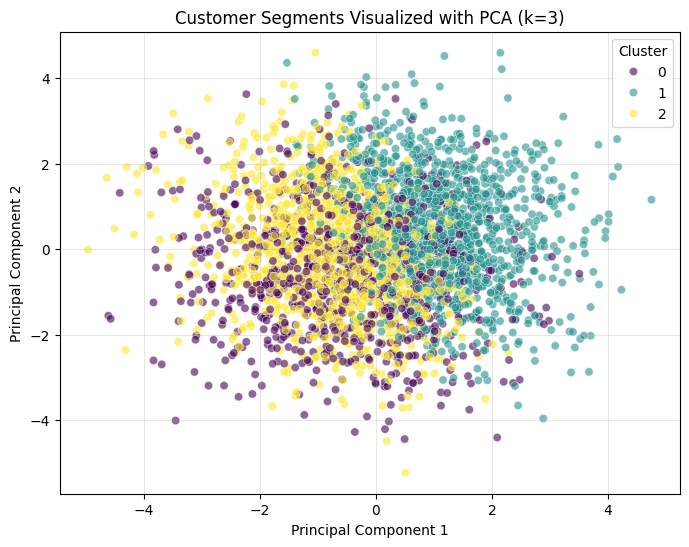

In [12]:
pca= PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.6)
plt.title(f'Customer Segments Visualized with PCA (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# Interet clusters


=== Cluster Sizes ===
Cluster
0     915
1    1219
2    1199
Name: count, dtype: int64

=== Cluster Profiles (mean values) ===
         Total day minutes  Total eve minutes  Total night minutes  \
Cluster                                                              
0               179.792459         202.970055           201.510929   
1               147.878753         184.472765           207.407957   
2               212.190242         216.244871           193.739533   

         Total intl minutes  Customer service calls     Churn  
Cluster                                                        
0                 10.228852                1.524590  0.087432  
1                 11.486792                1.635767  0.123872  
2                  8.973394                1.517932  0.210175  


/tmp/ipykernel_16/2190324332.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Cluster', y=feat, ax=ax, palette='viridis')
/tmp/ipykernel_16/2190324332.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Cluster', y=feat, ax=ax, palette='viridis')
/tmp/ipykernel_16/2190324332.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Cluster', y=feat, ax=ax, palette='viridis')
/tmp/ipykernel_16/2190324332.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

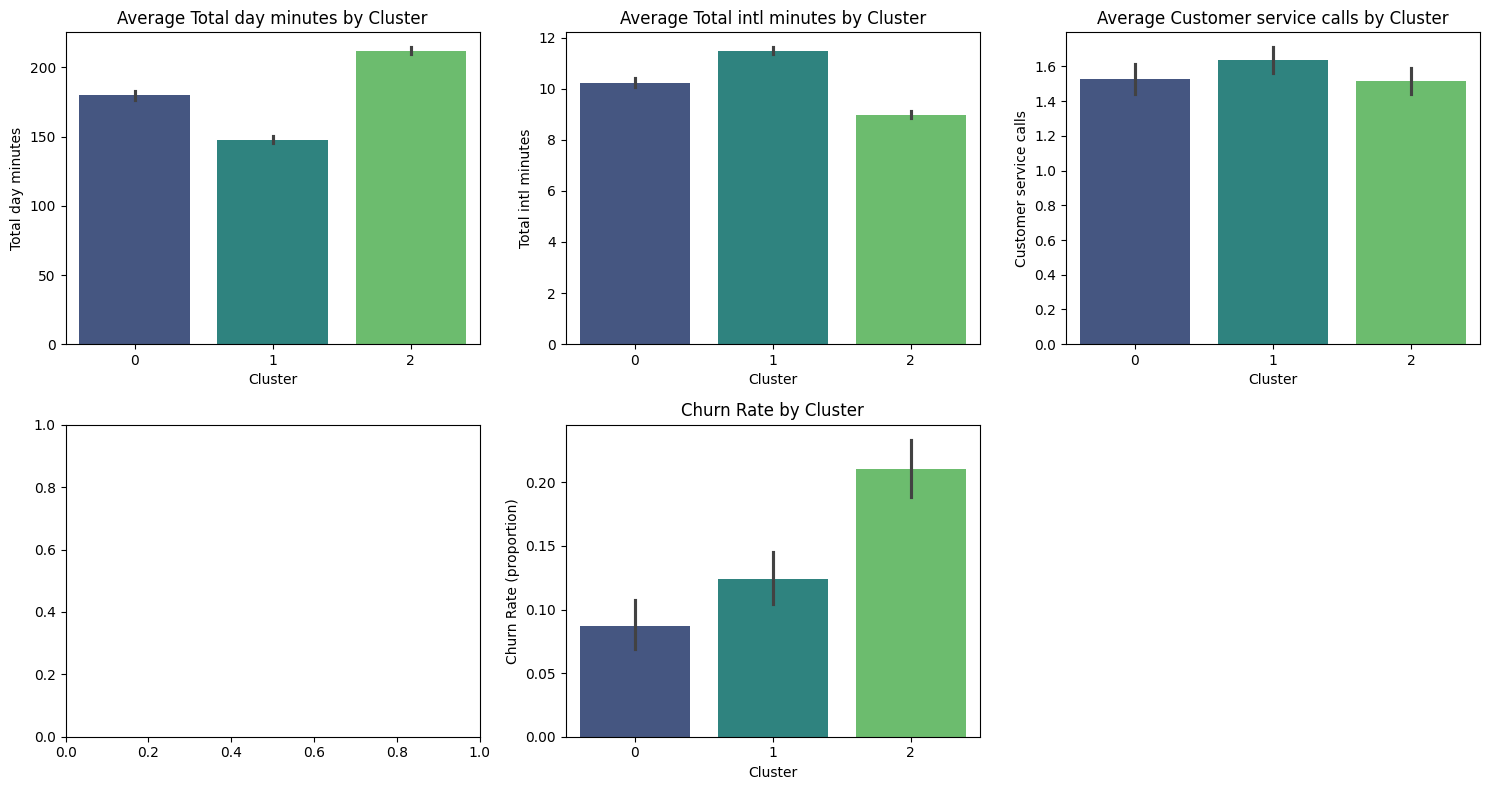

In [13]:
# Cluster sizes
print("\n=== Cluster Sizes ===")
print(df['Cluster'].value_counts().sort_index())

# Mean values of key features per cluster (including Churn for validation)
key_features = ['Total day minutes', 'Total eve minutes', 'Total night minutes',
                'Total intl minutes', 'Customer service calls', 'Churn']
# Convert Churn to numeric (True=1, False=0) for mean calculation
df['Churn_num'] = df['Churn'].astype(int) if df['Churn'].dtype == bool else df['Churn']

cluster_profile = df.groupby('Cluster')[key_features].mean()
print("\n=== Cluster Profiles (mean values) ===")
print(cluster_profile)

# Optional: Bar plot comparing clusters on selected features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_to_plot = ['Total day minutes', 'Total intl minutes', 'Customer service calls']
for i, feat in enumerate(features_to_plot):
    ax = axes[i//3, i%3]
    sns.barplot(data=df, x='Cluster', y=feat, ax=ax, palette='viridis')
    ax.set_title(f'Average {feat} by Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feat)

# Plot churn rate by cluster
ax = axes[1, 1]
sns.barplot(data=df, x='Cluster', y='Churn_num', ax=ax, palette='viridis')
ax.set_title('Churn Rate by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Churn Rate (proportion)')

axes[1,2].axis('off')
plt.tight_layout()
plt.show()


# SUMMARY OF FINDINGS

In [14]:
print("\n=== SUMMARY OF CLUSTERING RESULTS ===")
print(f"• Number of clusters selected: {optimal_k} (based on elbow/silhouette)")
print("• Cluster interpretations:")
for c in range(optimal_k):
    size = (df['Cluster'] == c).sum()
    avg_calls = df[df['Cluster'] == c]['Customer service calls'].mean()
    avg_day_min = df[df['Cluster'] == c]['Total day minutes'].mean()
    churn_rate = df[df['Cluster'] == c]['Churn_num'].mean()
    print(f"\n  Cluster {c}: {size} customers ({size/len(df)*100:.1f}%)")
    print(f"    - Avg customer service calls: {avg_calls:.1f}")
    print(f"    - Avg total day minutes: {avg_day_min:.1f}")
    print(f"    - Churn rate: {churn_rate:.1%}")


=== SUMMARY OF CLUSTERING RESULTS ===
• Number of clusters selected: 3 (based on elbow/silhouette)
• Cluster interpretations:

  Cluster 0: 915 customers (27.5%)
    - Avg customer service calls: 1.5
    - Avg total day minutes: 179.8
    - Churn rate: 8.7%

  Cluster 1: 1219 customers (36.6%)
    - Avg customer service calls: 1.6
    - Avg total day minutes: 147.9
    - Churn rate: 12.4%

  Cluster 2: 1199 customers (36.0%)
    - Avg customer service calls: 1.5
    - Avg total day minutes: 212.2
    - Churn rate: 21.0%
